In [1]:
import pandas as pd
weather = pd.read_csv("D:\\paper\\C\\data\\5\\corrhoulyweatherdata.csv", index_col="date")

In [2]:
weather
weather.dtypes

hour                int64
wind_direction      int64
wind_speed          int64
drybulb_temp      float64
rel_humid           int64
solarhour         float64
dtype: object

In [3]:
null_pct=weather.apply(pd.isnull).sum()/weather.shape[0]


In [4]:
weather.apply(pd.isnull).sum()

hour                  0
wind_direction        0
wind_speed            0
drybulb_temp          0
rel_humid             0
solarhour         25354
dtype: int64

In [5]:
null_pct

hour              0.000000
wind_direction    0.000000
wind_speed        0.000000
drybulb_temp      0.000000
rel_humid         0.000000
solarhour         0.875272
dtype: float64

In [6]:
valid_columns = weather.columns[null_pct < 0.9]

In [7]:
valid_columns

Index(['hour', 'wind_direction', 'wind_speed', 'drybulb_temp', 'rel_humid',
       'solarhour'],
      dtype='object')

In [8]:
weather = weather[valid_columns].copy()

In [9]:
weather.columns = weather.columns.str.lower()

In [10]:
weather

,hour,wind_direction,wind_speed,drybulb_temp,rel_humid,solarhour
date,,,,,,
1/1/2013,0,80,2,-3.4,97,NaN
1/1/2013,3,90,3,-5.0,90,NaN
1/1/2013,6,90,7,-2.6,83,NaN
1/1/2013,9,70,3,1.0,62,NaN
1/1/2013,12,70,6,0.6,61,NaN
...,...,...,...,...,...,...
12/1/2022,6,40,5,10.0,57,NaN
12/1/2022,9,90,4,14.5,40,NaN
12/1/2022,12,110,2,16.6,31,NaN


In [11]:
weather = weather.ffill()

In [12]:
weather.apply(pd.isnull).sum()

hour              0
wind_direction    0
wind_speed        0
drybulb_temp      0
rel_humid         0
solarhour         6
dtype: int64

In [13]:
weather.dtypes

hour                int64
wind_direction      int64
wind_speed          int64
drybulb_temp      float64
rel_humid           int64
solarhour         float64
dtype: object

In [14]:
weather.index

Index(['1/1/2013', '1/1/2013', '1/1/2013', '1/1/2013', '1/1/2013', '1/1/2013',
       '1/1/2013', '1/1/2013', '1/2/2013', '1/2/2013',
       ...
       '11/30/2022', '11/30/2022', '11/30/2022', '12/1/2022', '12/1/2022',
       '12/1/2022', '12/1/2022', '12/1/2022', '12/1/2022', '12/1/2022'],
      dtype='object', name='date', length=28967)

In [15]:
weather.index = pd.to_datetime(weather.index)

In [16]:
weather.index

DatetimeIndex(['2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-02', '2013-01-02',
               ...
               '2022-11-30', '2022-11-30', '2022-11-30', '2022-12-01',
               '2022-12-01', '2022-12-01', '2022-12-01', '2022-12-01',
               '2022-12-01', '2022-12-01'],
              dtype='datetime64[ns]', name='date', length=28967, freq=None)

In [17]:
weather.index.date

array([datetime.date(2013, 1, 1), datetime.date(2013, 1, 1),
       datetime.date(2013, 1, 1), ..., datetime.date(2022, 12, 1),
       datetime.date(2022, 12, 1), datetime.date(2022, 12, 1)],
      dtype=object)

In [18]:
weather.index.year.value_counts().sort_index()

2013    2947
2014    2901
2015    2915
2016    2927
2017    2918
2018    2920
2019    2920
2020    2920
2021    2920
2022    2679
Name: date, dtype: int64

<Figure size 1000x500 with 0 Axes>

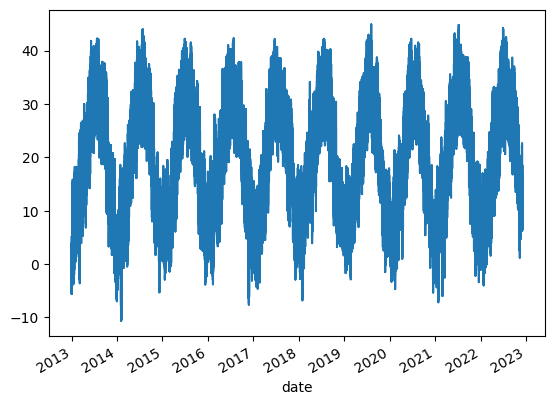

<Figure size 1000x500 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

weather["drybulb_temp"].plot()
plt.figure(figsize=(10, 5))

In [22]:
#predict
weather["target"] = weather.shift(-1)['drybulb_temp']

In [23]:
weather

,hour,wind_direction,wind_speed,drybulb_temp,rel_humid,solarhour,target
date,,,,,,,
2013-01-01,0,80,2,-3.4,97,NaN,-5.0
2013-01-01,3,90,3,-5.0,90,NaN,-2.6
2013-01-01,6,90,7,-2.6,83,NaN,1.0
2013-01-01,9,70,3,1.0,62,NaN,0.6
2013-01-01,12,70,6,0.6,61,NaN,-2.4
...,...,...,...,...,...,...,...
2022-12-01,6,40,5,10.0,57,9.1,14.5
2022-12-01,9,90,4,14.5,40,9.1,16.6
2022-12-01,12,110,2,16.6,31,9.1,12.7


In [33]:
weather = weather.ffill()

In [34]:
weather

,hour,wind_direction,wind_speed,drybulb_temp,rel_humid,solarhour,target
date,,,,,,,
2013-01-01,0,80,2,-3.4,97,NaN,-5.0
2013-01-01,3,90,3,-5.0,90,NaN,-2.6
2013-01-01,6,90,7,-2.6,83,NaN,1.0
2013-01-01,9,70,3,1.0,62,NaN,0.6
2013-01-01,12,70,6,0.6,61,NaN,-2.4
...,...,...,...,...,...,...,...
2022-12-01,6,40,5,10.0,57,9.1,14.5
2022-12-01,9,90,4,14.5,40,9.1,16.6
2022-12-01,12,110,2,16.6,31,9.1,12.7


In [26]:
from sklearn.linear_model import Ridge

In [27]:
weather.corr()

,hour,wind_direction,wind_speed,drybulb_temp,rel_humid,solarhour,target
hour,1.000000,0.049063,-0.007941,0.080097,-0.097065,-0.000017,-0.099999
wind_direction,0.049063,1.000000,0.289586,0.097338,-0.073081,-0.045140,0.050145
wind_speed,-0.007941,0.289586,1.000000,0.247580,-0.186378,0.200568,0.255030
drybulb_temp,0.080097,0.097338,0.247580,1.000000,-0.754325,0.564143,0.949604
rel_humid,-0.097065,-0.073081,-0.186378,-0.754325,1.000000,-0.621623,-0.699885
solarhour,-0.000017,-0.045140,0.200568,0.564143,-0.621623,1.000000,0.567796
target,-0.099999,0.050145,0.255030,0.949604,-0.699885,0.567796,1.000000


In [28]:
#apply ml

rr = Ridge(alpha=.1)

In [29]:
#apply Rodge regression

predictors = weather.columns[~weather.columns.isin(['target', 'date'])]

In [30]:
predictors

Index(['hour', 'wind_direction', 'wind_speed', 'drybulb_temp', 'rel_humid',
       'solarhour'],
      dtype='object')

In [31]:
#account for
def backtest(weather, model, predictors, start=1, step=1):
    all_predictions = []
    
    for i in range(start, weather.shape[0], step):
        train = weather.iloc[:i,:]
        test = weather.iloc[i:(i+step),:]
        
        model.fit(train[predictors], train["target"])
        
        preds = model.predict(test[predictors])
        
        preds  = pd.Series(preds, index=test.index)
        combined = pd.concat([test["target"], preds], axis=1)
        
        combined.columns = ['actual', 'prediction']
        
        combined["diff"] = (combined["prediction"]-combined["actual"]).abs()
        
        all_predictions.append(combined)
    return pd.concat(all_predictions)

In [32]:
predictions = backtest(weather, rr, predictors)

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [175]:
predictions

NameError: name 'predictions' is not defined

In [54]:
#how effective/ accurate
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import RMSE


mean_absolute_error(predictions['actual'], predictions['prediction'])

ImportError: cannot import name 'RMSE' from 'sklearn.metrics' (C:\Users\Vahid\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\metrics\__init__.py)

In [34]:
predictions['diff'].mean()

671.5783933067069

In [35]:
#improve accuracy
def pct_diff(old, new):
    return (new - old) / old

def compute_rolling(weather, horizon, col):
    label = f"rolling_{horizon}-{col}"
    
    weather[label] = weather[col].rolling(horizon).mean()
    weather[f"{label}-pct"] = pct_diff(weather[label], weather[col])
    return weather

rolling_horizons = [2, 2]

for horizon in rolling_horizons:
    for col in["requests", "temp", "solar hour"]:
        weather = compute_rolling(weather, horizon, col)

In [36]:
weather

,requests,wind speed,solar hour,rel humid,temp,target,rolling_2-requests,rolling_2-requests-pct,rolling_2-temp,rolling_2-temp-pct,rolling_2-solar hour,rolling_2-solar hour-pct
date,,,,,,,,,,,,
2013-01-01,826.666667,4.145161,374.8,38.0,17.4,130.340909,NaN,NaN,NaN,NaN,NaN,NaN
2013-02-01,130.340909,4.567742,303.7,33.0,20.9,101.216966,478.503788,-7.276074e-01,19.15,0.091384,339.25,-0.104790
2013-03-01,101.216966,5.412903,337.4,22.0,28.6,72.093023,115.778938,-1.257739e-01,24.75,0.155556,320.55,0.052566
2013-04-01,72.093023,5.374194,366.8,21.0,31.2,37.959184,86.654995,-1.680454e-01,29.90,0.043478,352.10,0.041750
2013-05-01,37.959184,5.270968,348.1,22.0,31.1,56.479592,55.026103,-3.101604e-01,31.15,-0.001605,357.45,-0.026158
2013-06-01,56.479592,4.590323,337.5,20.0,28.9,75.000000,47.219388,1.961102e-01,30.00,-0.036667,342.80,-0.015461
2013-07-01,75.000000,4.153333,292.8,26.0,23.1,1120.408163,65.739796,1.408615e-01,26.00,-0.111538,315.15,-0.070919
2013-08-01,1120.408163,3.470000,207.4,45.0,13.5,2051.870748,597.704082,8.745198e-01,18.30,-0.262295,250.10,-0.170732
2013-09-01,2051.870748,3.060000,178.6,56.0,8.5,2983.333333,1586.139455,2.936257e-01,11.00,-0.227273,193.00,-0.074611


In [37]:
weather = weather.iloc[2:,:]

In [38]:
weather

,requests,wind speed,solar hour,rel humid,temp,target,rolling_2-requests,rolling_2-requests-pct,rolling_2-temp,rolling_2-temp-pct,rolling_2-solar hour,rolling_2-solar hour-pct
date,,,,,,,,,,,,
2013-03-01,101.216966,5.412903,337.4,22.0,28.6,72.093023,115.778938,-1.257739e-01,24.75,0.155556,320.55,0.052566
2013-04-01,72.093023,5.374194,366.8,21.0,31.2,37.959184,86.654995,-1.680454e-01,29.90,0.043478,352.10,0.041750
2013-05-01,37.959184,5.270968,348.1,22.0,31.1,56.479592,55.026103,-3.101604e-01,31.15,-0.001605,357.45,-0.026158
2013-06-01,56.479592,4.590323,337.5,20.0,28.9,75.000000,47.219388,1.961102e-01,30.00,-0.036667,342.80,-0.015461
2013-07-01,75.000000,4.153333,292.8,26.0,23.1,1120.408163,65.739796,1.408615e-01,26.00,-0.111538,315.15,-0.070919
2013-08-01,1120.408163,3.470000,207.4,45.0,13.5,2051.870748,597.704082,8.745198e-01,18.30,-0.262295,250.10,-0.170732
2013-09-01,2051.870748,3.060000,178.6,56.0,8.5,2983.333333,1586.139455,2.936257e-01,11.00,-0.227273,193.00,-0.074611
2013-10-01,2983.333333,2.733333,167.4,53.0,3.2,2526.666667,2517.602040,1.849900e-01,5.85,-0.452991,173.00,-0.032370
2013-11-01,2526.666667,3.233333,225.5,43.0,5.3,1890.931373,2755.000000,-8.287961e-02,4.25,0.247059,196.45,0.147875


In [39]:
weather = weather.fillna(0)

In [40]:
weather[weather.index.duplicated()]

,requests,wind speed,solar hour,rel humid,temp,target,rolling_2-requests,rolling_2-requests-pct,rolling_2-temp,rolling_2-temp-pct,rolling_2-solar hour,rolling_2-solar hour-pct
date,,,,,,,,,,,,


In [41]:
weather = weather[~weather.index.duplicated()]

In [42]:
def expand_mean(df):
    return df.expanding(1).mean()

#add columns
for col in["requests", "temp", "solar hour"]:
    weather[f"month_avg_{col}"] = weather[col].groupby(weather.index.month, group_keys=False).apply(expand_mean)
    weather[f"day_avg_{col}"] = weather[col].groupby(weather.index.day, group_keys=False).apply(expand_mean)

In [43]:
weather

,requests,wind speed,solar hour,rel humid,temp,target,rolling_2-requests,rolling_2-requests-pct,rolling_2-temp,rolling_2-temp-pct,rolling_2-solar hour,rolling_2-solar hour-pct,month_avg_requests,day_avg_requests,month_avg_temp,day_avg_temp,month_avg_solar hour,day_avg_solar hour
date,,,,,,,,,,,,,,,,,,
2013-03-01,101.216966,5.412903,337.4,22.0,28.6,72.093023,115.778938,-1.257739e-01,24.75,0.155556,320.55,0.052566,101.216966,101.216966,28.600000,28.600000,337.400000,337.400000
2013-04-01,72.093023,5.374194,366.8,21.0,31.2,37.959184,86.654995,-1.680454e-01,29.90,0.043478,352.10,0.041750,72.093023,86.654995,31.200000,29.900000,366.800000,352.100000
2013-05-01,37.959184,5.270968,348.1,22.0,31.1,56.479592,55.026103,-3.101604e-01,31.15,-0.001605,357.45,-0.026158,37.959184,70.423058,31.100000,30.300000,348.100000,350.766667
2013-06-01,56.479592,4.590323,337.5,20.0,28.9,75.000000,47.219388,1.961102e-01,30.00,-0.036667,342.80,-0.015461,56.479592,66.937191,28.900000,29.950000,337.500000,347.450000
2013-07-01,75.000000,4.153333,292.8,26.0,23.1,1120.408163,65.739796,1.408615e-01,26.00,-0.111538,315.15,-0.070919,75.000000,68.549753,23.100000,28.580000,292.800000,336.520000
2013-08-01,1120.408163,3.470000,207.4,45.0,13.5,2051.870748,597.704082,8.745198e-01,18.30,-0.262295,250.10,-0.170732,1120.408163,243.859488,13.500000,26.066667,207.400000,315.000000
2013-09-01,2051.870748,3.060000,178.6,56.0,8.5,2983.333333,1586.139455,2.936257e-01,11.00,-0.227273,193.00,-0.074611,2051.870748,502.146811,8.500000,23.557143,178.600000,295.514286
2013-10-01,2983.333333,2.733333,167.4,53.0,3.2,2526.666667,2517.602040,1.849900e-01,5.85,-0.452991,173.00,-0.032370,2983.333333,812.295126,3.200000,21.012500,167.400000,279.500000
2013-11-01,2526.666667,3.233333,225.5,43.0,5.3,1890.931373,2755.000000,-8.287961e-02,4.25,0.247059,196.45,0.147875,2526.666667,1002.780853,5.300000,19.266667,225.500000,273.500000


In [44]:
predictors=weather.columns[~weather.columns.isin(['target', 'date'])]

In [45]:
predictors

Index(['requests', 'wind speed', 'solar hour', 'rel humid', 'temp',
       'rolling_2-requests', 'rolling_2-requests-pct', 'rolling_2-temp',
       'rolling_2-temp-pct', 'rolling_2-solar hour',
       'rolling_2-solar hour-pct', 'month_avg_requests', 'day_avg_requests',
       'month_avg_temp', 'day_avg_temp', 'month_avg_solar hour',
       'day_avg_solar hour'],
      dtype='object')

In [46]:
predictions = backtest(weather, rr, predictors)

In [47]:
mean_absolute_error(predictions['actual'], predictions['prediction'])

1342.8634489552635

In [48]:
predictions.sort_values('diff', ascending=False)

,actual,prediction,diff
date,,,
2013-08-01,2051.870748,25464.423653,23412.552905
2013-09-01,2983.333333,12436.358605,9453.025272
2014-05-01,87.262644,-4334.883628,4422.146272
2014-08-01,2101.160542,-1656.236013,3757.396555
2014-11-01,2076.869565,4962.580369,2885.710804
2014-03-01,59.047619,-2294.898842,2353.946461
2017-12-01,1967.719919,112.547973,1855.171946
2014-06-01,123.913044,1748.680004,1624.766961
2017-01-01,105.531915,-1416.084330,1521.616245


In [49]:
weather.loc["2015-01-01":"2017-01-12"]

,requests,wind speed,solar hour,rel humid,temp,target,rolling_2-requests,rolling_2-requests-pct,rolling_2-temp,rolling_2-temp-pct,rolling_2-solar hour,rolling_2-solar hour-pct,month_avg_requests,day_avg_requests,month_avg_temp,day_avg_temp,month_avg_solar hour,day_avg_solar hour
date,,,,,,,,,,,,,,,,,,
2015-01-01,1457.000000,4.0,236.7,46.0,17.1,126.296296,1766.934782,-1.754082e-01,12.95,0.320463,212.30,0.114932,1356.098039,1097.644873,15.950000,18.517391,243.550000,262.356522
2015-02-01,126.296296,4.0,300.1,29.0,24.4,79.904905,791.648148,-8.404641e-01,20.75,0.175904,268.40,0.118107,126.557239,1057.172016,23.800000,18.762500,285.150000,263.929167
2015-03-01,79.904905,5.0,334.4,17.0,29.9,33.513514,103.100601,-2.249812e-01,27.15,0.101289,317.25,0.054058,91.351591,1018.081331,28.900000,19.208000,333.233333,266.748000
2015-04-01,33.513514,5.0,347.7,19.0,32.4,69.591837,56.709209,-4.090287e-01,31.15,0.040128,341.05,0.019499,54.884719,980.213338,31.900000,19.715385,362.333333,269.861538
2015-05-01,69.591837,4.0,377.3,16.0,30.6,96.752440,51.552675,3.499171e-01,31.50,-0.028571,362.50,0.040828,52.721088,946.486616,31.033333,20.118519,366.100000,273.840741
2015-06-01,96.752440,4.0,321.4,26.0,25.8,123.913044,83.172138,1.632795e-01,28.20,-0.085106,349.35,-0.080006,80.164892,916.138967,27.766667,20.321429,331.733333,275.539286
2015-07-01,123.913044,4.0,282.2,34.0,22.0,1657.142857,110.332742,1.230850e-01,23.90,-0.079498,301.80,-0.064944,107.608696,888.820832,22.233333,20.379310,277.200000,275.768966
2015-08-01,1657.142857,3.0,194.9,48.0,13.6,2495.616883,890.527950,8.608544e-01,17.80,-0.235955,238.55,-0.182981,1371.304885,914.431566,12.933333,20.153333,210.633333,273.073333
2015-09-01,2495.616883,3.0,203.2,54.0,7.2,3334.090909,2076.379870,2.019077e-01,10.40,-0.307692,199.05,0.020849,2216.216058,965.437544,7.766667,19.735484,183.033333,270.819355


In [50]:
predictions['diff'].round().value_counts()

34.0       1
846.0      1
966.0      1
266.0      1
426.0      1
68.0       1
177.0      1
505.0      1
27.0       1
294.0      1
30.0       1
985.0      1
726.0      1
959.0      1
304.0      1
109.0      1
1522.0     1
866.0      1
53.0       1
189.0      1
483.0      1
469.0      1
536.0      1
1030.0     1
1131.0     1
46.0       1
235.0      1
125.0      1
174.0      1
32.0       1
1091.0     1
6.0        1
997.0      1
23413.0    1
9453.0     1
382.0      1
1228.0     1
1479.0     1
933.0      1
1317.0     1
2354.0     1
1276.0     1
4422.0     1
1625.0     1
463.0      1
3757.0     1
12.0       1
784.0      1
2886.0     1
674.0      1
16.0       1
878.0      1
626.0      1
123.0      1
144.0      1
737.0      1
1855.0     1
Name: diff, dtype: int64

In [51]:
predictions['diff'].round().value_counts().sort_index()

6.0        1
12.0       1
16.0       1
27.0       1
30.0       1
32.0       1
34.0       1
46.0       1
53.0       1
68.0       1
109.0      1
123.0      1
125.0      1
144.0      1
174.0      1
177.0      1
189.0      1
235.0      1
266.0      1
294.0      1
304.0      1
382.0      1
426.0      1
463.0      1
469.0      1
483.0      1
505.0      1
536.0      1
626.0      1
674.0      1
726.0      1
737.0      1
784.0      1
846.0      1
866.0      1
878.0      1
933.0      1
959.0      1
966.0      1
985.0      1
997.0      1
1030.0     1
1091.0     1
1131.0     1
1228.0     1
1276.0     1
1317.0     1
1479.0     1
1522.0     1
1625.0     1
1855.0     1
2354.0     1
2886.0     1
3757.0     1
4422.0     1
9453.0     1
23413.0    1
Name: diff, dtype: int64

<AxesSubplot:>

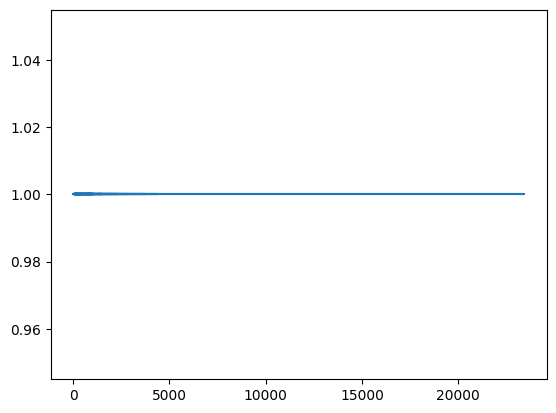

In [53]:
predictions['diff'].round().value_counts().plot()